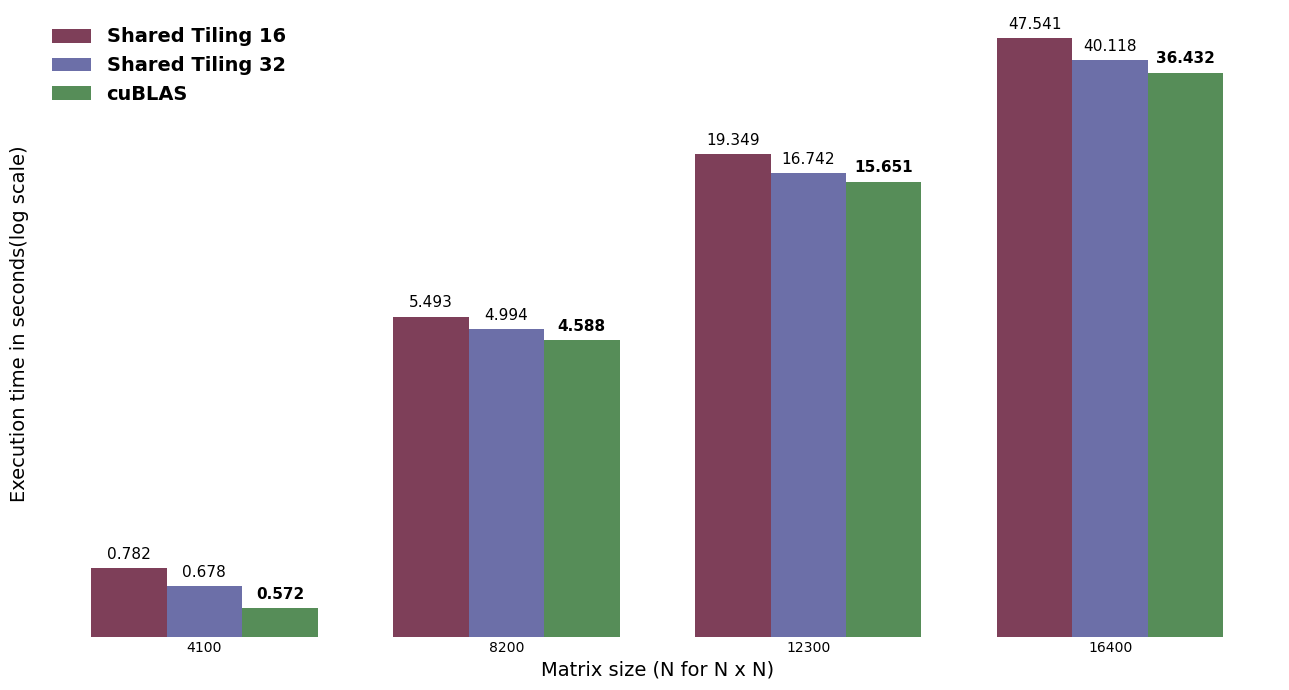

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Custom color palette
colors = ["#568D58", "#7E3F59", "#6C6FA8"]

# Load the CSV file
df = pd.read_csv("cuda_matrix_benchmark_times.csv")

# Keep only the rows you want to plot if needed
# Example:
# df = df[df["matrix_size"].isin(["4096*4096", "8192*8192", "12288*12288", "20480*20480"])]

# Create x-axis labels from matrix_size
df["matrix_label"] = df["matrix_size"].str.split("*").str[0]

x = np.arange(len(df))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(13, 7))

# Plot grouped bars
bars_t16 = ax.bar(
    x - bar_width,
    df["shared_tiling_16_time"],
    width=bar_width,
    label="Shared Tiling 16",
    color=colors[1],
    edgecolor="none"
)

bars_t32 = ax.bar(
    x,
    df["shared_tiling_32_time"],
    width=bar_width,
    label="Shared Tiling 32",
    color=colors[2],
    edgecolor="none"
)

bars_cublas = ax.bar(
    x + bar_width,
    df["cublas_time"],
    width=bar_width,
    label="cuBLAS",
    color=colors[0],
    edgecolor="none"
)

# Log scale
ax.set_yscale("log")

# Title and x-axis label
#ax.set_title("CUDA Matrix Multiplication Benchmark")
ax.set_xlabel("Matrix size (N for N x N)", fontsize=14)

# X ticks
ax.set_xticks(x)
ax.set_xticklabels(df["matrix_label"])

ax.set_ylabel("Execution time in seconds(log scale)", fontsize=14)
ax.set_yticks([])
ax.tick_params(axis="y", which="both", left=False, right=False, labelleft=False, length=0)

# Remove spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)

# Remove x tick marks
ax.tick_params(axis="x", length=0)

# Remove grid
ax.grid(False)

# Legend
ax.legend(frameon=False, loc="upper left", prop={"size": 14, "weight": "bold"})
# Add labels and make the minimum value in each group bold
for i in range(len(df)):
    values = [
        df.iloc[i]["shared_tiling_16_time"],
        df.iloc[i]["shared_tiling_32_time"],
        df.iloc[i]["cublas_time"]
    ]
    
    min_value = min(values)

    group_bars = [bars_t16[i], bars_t32[i], bars_cublas[i]]
    
    for bar, value in zip(group_bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value * 1.05,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold" if value == min_value else "normal"
        )

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd

# Load benchmark data
df = pd.read_csv("cuda_matrix_benchmark_times.csv")

# Create a short matrix label
df["matrix_n"] = df["matrix_size"].str.split("*").str[0]

# Percentage improvement using Shared Tiling 16 as baseline
df["tiling32_improvement_pct"] = (
    (df["shared_tiling_16_time"] - df["shared_tiling_32_time"])
    / df["shared_tiling_16_time"]
) * 100

df["cublas_improvement_pct"] = (
    (df["shared_tiling_16_time"] - df["cublas_time"])
    / df["shared_tiling_16_time"]
) * 100

# Round values
df["tiling32_improvement_pct"] = df["tiling32_improvement_pct"].round(2)
df["cublas_improvement_pct"] = df["cublas_improvement_pct"].round(2)

# Final table
improvement_df = df[
    ["matrix_n", "tiling32_improvement_pct", "cublas_improvement_pct"]
].copy()

print(improvement_df)

# Optional: save to CSV
improvement_df.to_csv("cuda_matrix_improvement_from_tiling16.csv", index=False)

  matrix_n  tiling32_improvement_pct  cublas_improvement_pct
0     4100                     13.30                   26.85
1     8200                      9.08                   16.48
2    12300                     13.47                   19.11
3    16400                     15.61                   23.37
